

**Importing all the required libraries**

In [1]:
# Importing the libraries
import os
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, GRU, Bidirectional
from keras.optimizers import SGD
import math
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
import zipfile

2025-10-04 19:22:27.016544: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-04 19:22:27.016660: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-04 19:22:27.131140: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
# !unzip /content/archive.zip
# For Google Colab Execution

In [3]:
# Some functions to help out with
def plot_predictions(test,predicted):
    plt.plot(test, color='red',label='Real PWR')
    plt.plot(predicted, color='green',label='Predicted PWR')
    plt.title('Demand Prediction')
    plt.xlabel('Time')
    plt.ylabel('Prediction')
    plt.title("GRU Model 1 Day Prediction")
    plt.legend()
    plt.show()

# Calculation of Root Mean Squared-Error
def return_rmse(test,predicted):
    rmse = math.sqrt(mean_squared_error(test, predicted))
    print("The root mean squared error is {}.".format(rmse))

# Calculation of Mean Absolute Error
def return_mae(test,predicted):
    rmse = math.sqrt(mean_absolute_error(test, predicted))
    print("The mean absolute error is {}.".format(rmse))

# Calculation of R2 Score
def return_r2(test,predicted):
    rmse = math.sqrt(r2_score(test, predicted))
    print("The r2 score is {}.".format(rmse))

In [4]:
df=pd.read_excel('/kaggle/input/lf-data/__2324.xlsx')

In [5]:
# # Ensure Date N Time column is datetime
# df['Date N Time'] = pd.to_datetime(df['Date N Time'])

# # Create a week identifier (Year-Week)
# df['YearWeek'] = df['Date N Time'].dt.to_period('W')

# # Replace zeros with weekly mean (ignoring zeros)
# for col in df.select_dtypes(include=['int64', 'float64']).columns:
#     df[col] = df.groupby('YearWeek')[col].transform(
#         lambda x: x.replace(0, x[x != 0].mean())
#     )

# # Drop helper column if not needed
# df.drop(columns=['YearWeek'], inplace=True)

# # Replace NaNs with zeros
# df.fillna(0, inplace=True)


In [6]:
# df.reset_index(inplace=True, drop=True)
# df['Date N Time'] = pd.to_datetime(df['Date N Time'], dayfirst=True, errors='coerce')

In [7]:
df['Date N Time'] = pd.to_datetime(df['Date N Time'])

In [8]:
df.set_index('Date N Time', inplace=True)

In [9]:
print(type(df.index))

<class 'pandas.core.indexes.datetimes.DatetimeIndex'>


In [10]:
df.columns

Index(['M1_PWR', 'M2_PWR', 'M3_PWR'], dtype='object')

In [11]:
df = df.sort_values(by='Date N Time')

In [12]:
df.shape

(184560, 3)

In [13]:
df.columns

Index(['M1_PWR', 'M2_PWR', 'M3_PWR'], dtype='object')

In [14]:
df.describe()

,M1_PWR,M2_PWR,M3_PWR
count,184560.000000,184560.000000,184560.000000
mean,-80.583934,-80.634833,-80.515800
std,92.393289,92.426647,92.280570
min,-368.607178,-368.465271,-358.871857
25%,-163.929127,-163.988728,-163.740891
50%,-96.879768,-96.847389,-96.737259
75%,0.000000,0.000000,0.000000
max,188.991653,188.900467,188.037827


In [15]:
df_refined=df['M2_PWR'].resample('6min').mean()

In [16]:
df_refined.isnull().sum()

6121

In [17]:
df_refined.describe()

count    169680.000000
mean        -81.331008
std          92.493865
min        -368.465271
25%        -164.492714
50%         -99.373631
75%           0.000000
max         188.900467
Name: M2_PWR, dtype: float64

In [18]:
df_refined[0:10]

Date N Time
2022-12-30 17:24:00      0.000000
2022-12-30 17:30:00      0.000000
2022-12-30 17:36:00      0.135751
2022-12-30 17:42:00    107.279305
2022-12-30 17:48:00   -119.334167
2022-12-30 17:54:00   -206.792053
2022-12-30 18:00:00   -229.962585
2022-12-30 18:06:00   -224.225677
2022-12-30 18:12:00   -220.028198
2022-12-30 18:18:00   -215.626312
Freq: 6min, Name: M2_PWR, dtype: float64

In [19]:
# df['M1_PWR_CLEANED'] = df['M1_PWR'].replace(0, np.nan)

In [20]:
df_refined.fillna(0, inplace=True)

In [21]:
df_refined[236:244]

Date N Time
2022-12-31 17:00:00   -132.211258
2022-12-31 17:06:00   -141.512283
2022-12-31 17:12:00   -138.836792
2022-12-31 17:18:00   -142.179169
2022-12-31 17:24:00      0.000000
2022-12-31 17:30:00      0.000000
2022-12-31 17:36:00      0.000000
2022-12-31 17:42:00      0.000000
Freq: 6min, Name: M2_PWR, dtype: float64

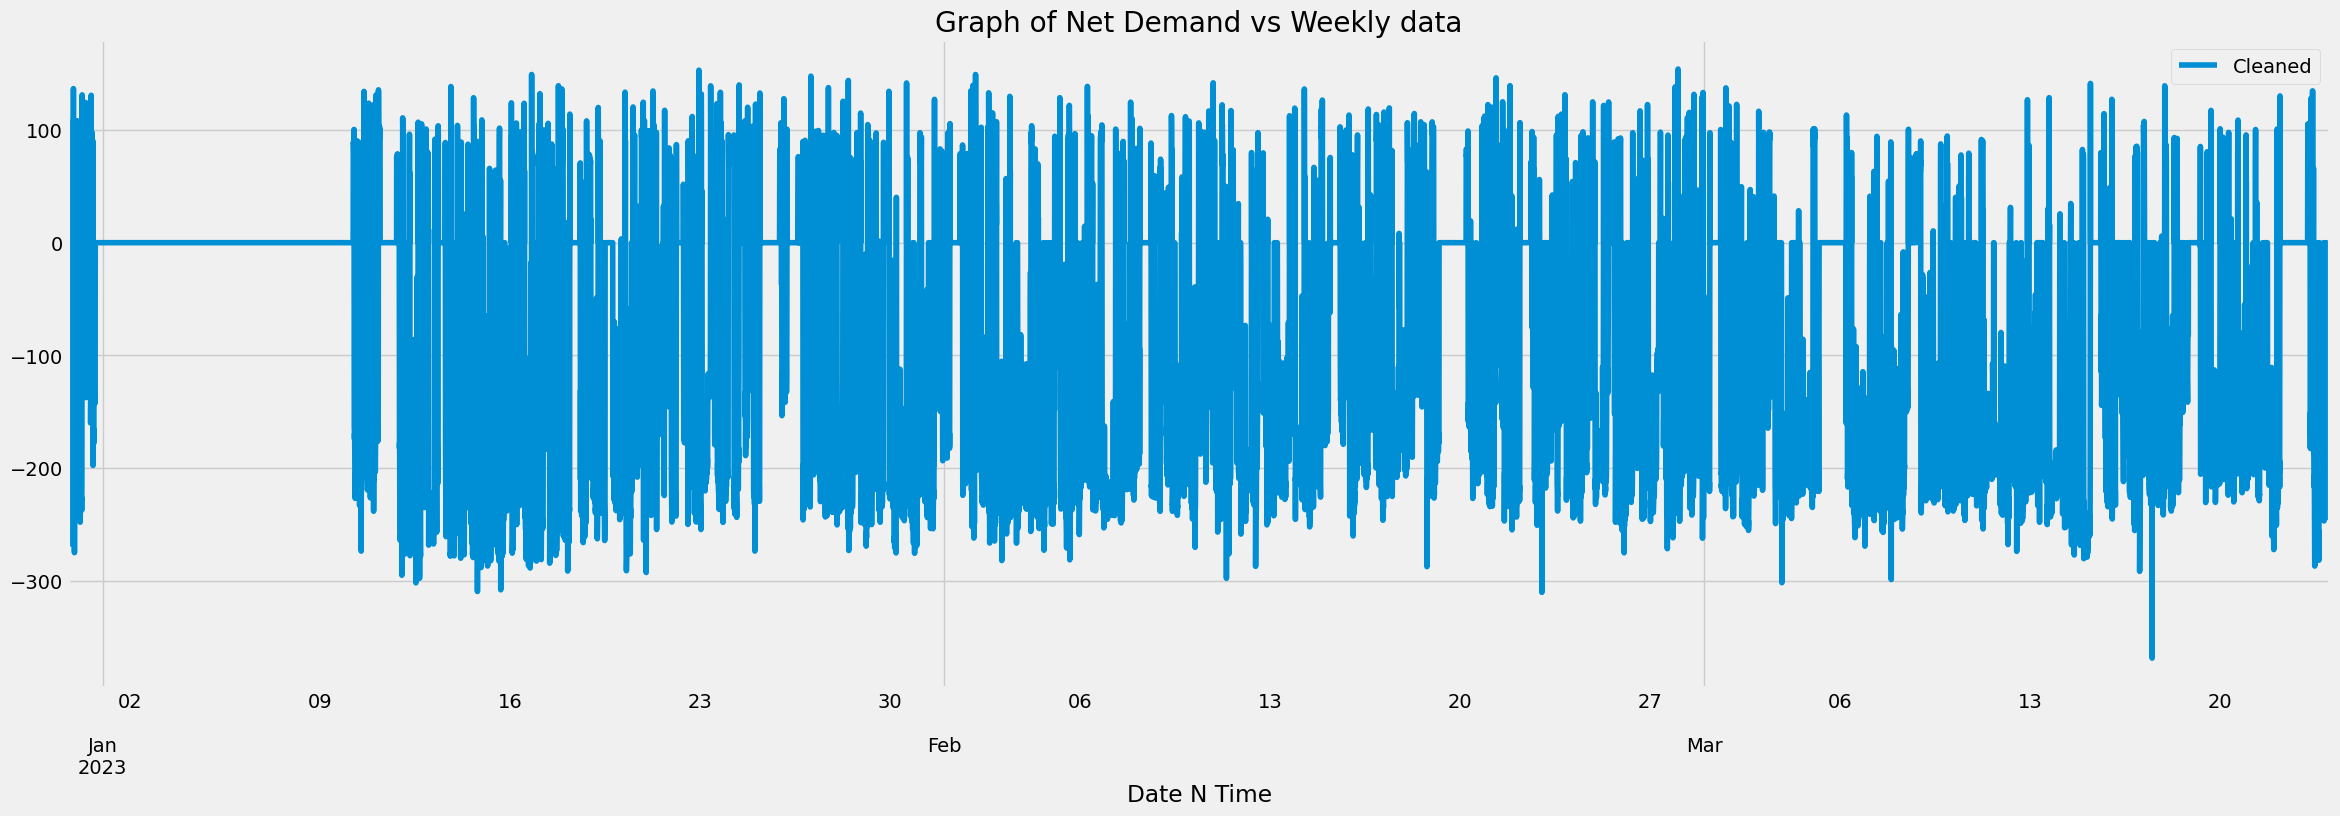

In [22]:
# df['M1_PWR_CLEANED'][0:1000].plot(figsize=(26,8),legend=True)
df_refined[0:20000].plot(figsize=(26,8),legend=True)
plt.legend(['Cleaned','As it is'])
plt.title('Graph of Net Demand vs Weekly data')
plt.show()

Here, we are trying to check the overall trend of the nat_demand

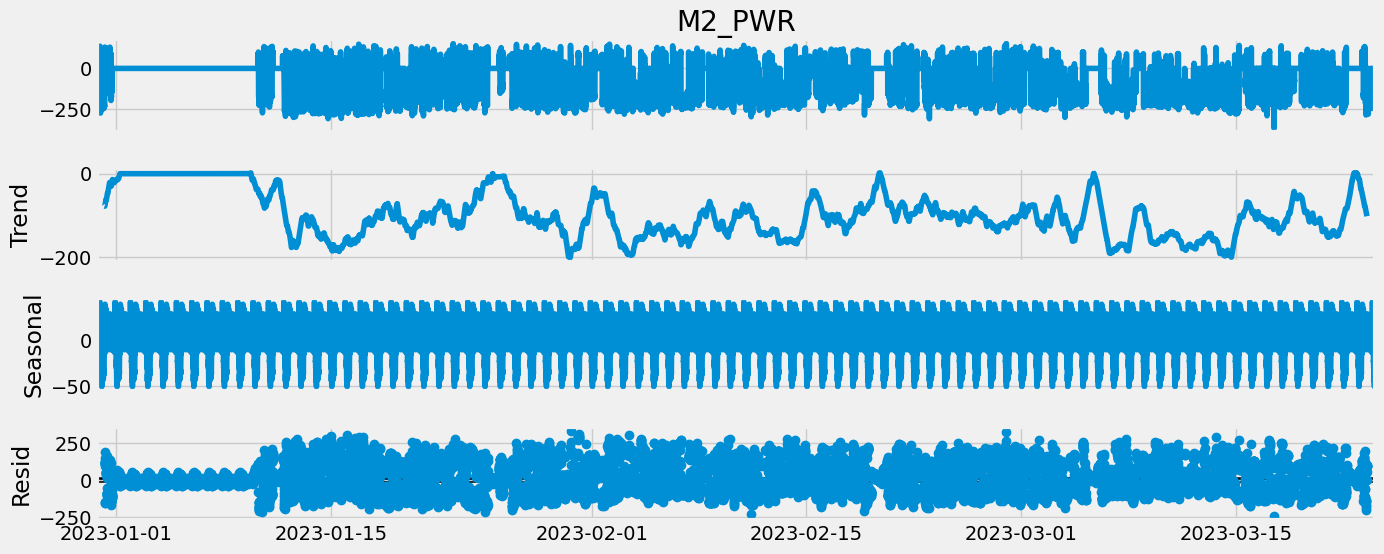

In [23]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomp = seasonal_decompose(df_refined[0:20000], model='additive', period=240)
fig = decomp.plot()
fig.set_figheight(6)
fig.set_figwidth(16)

In [24]:
# Checking for missing values
training_set = df_refined.values
training_set=training_set.reshape((training_set.shape[0],1))

In [25]:
print("Training Set Shape : ",training_set.shape)

Training Set Shape :  (175801, 1)


In [26]:
training_set[0]

array([0.])

In [27]:
X=training_set;

In [28]:
training_set

array([[ 0.00000000e+00],
       [ 0.00000000e+00],
       [ 1.35750502e-01],
       ...,
       [-1.65955917e+02],
       [-1.72801636e+02],
       [-5.33853722e+01]])

In [29]:
training_set.sum()

-13800245.519008746

In [30]:
#X_std = (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0))
#training_set_scaled = X_std * (2) - 1

**Scaling the training set from values 0 to 1**

In [31]:
sc = MinMaxScaler(feature_range=(-1,1))
training_set_scaled = sc.fit_transform(training_set)

In [32]:
training_set_scaled.shape

(175801, 1)

In [33]:
(training_set_scaled>=0).sum()

88736

In [34]:
(training_set_scaled<=0).sum()

87065

In [35]:
training_set_scaled

array([[ 0.32216692],
       [ 0.32216692],
       [ 0.32265404],
       ...,
       [-0.27333404],
       [-0.29789859],
       [ 0.13060376]])

In [36]:
X_train = []
Y_train = []

input_steps = 1000 # 10 hours of history
output_steps = 1   # Next 60 minutes

for i in range(input_steps, len(training_set_scaled) - output_steps):
    X_train.append(training_set_scaled[i-input_steps:i, 0])
    Y_train.append(training_set_scaled[i:i+output_steps, 0])

X_train, Y_train = np.array(X_train), np.array(Y_train)

# Reshape for LSTM/GRU
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

In [37]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

In [38]:
X_train.shape

(174800, 1000, 1)

In [39]:
Y_train.shape

(174800, 1)

In [40]:
# X_train = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0)
# Y_train = np.nan_to_num(Y_train, nan=0.0, posinf=0.0, neginf=0.0)

In [41]:
import numpy as np

print("X_train NaNs:", np.isnan(X_train).sum())
print("X_train Infs:", np.isinf(X_train).sum())
print("y_train NaNs:", np.isnan(Y_train).sum())
print("y_train Infs:", np.isinf(Y_train).sum())

X_train NaNs: 0
X_train Infs: 0
y_train NaNs: 0
y_train Infs: 0


**Our GRU Model**

In [42]:
from keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',       # You can also monitor 'val_mae' or 'val_r2_score'
    patience=5,               # Stop after 5 epochs with no improvement
    restore_best_weights=True # Roll back to the best weights
)


In [43]:
EPOCHS=5

from keras.models import Sequential
from keras.layers import GRU, LSTM, Dense, Dropout

model = Sequential()
model.add(GRU(128, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(GRU(64, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')
model.summary()

/opt/conda/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 1000, 128)      │        50,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 87,617 (342.25 KB)

 Trainable params: 87,617 (342.25 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
model.fit(X_train,Y_train, epochs=EPOCHS,batch_size=64, shuffle=False)

Epoch 1/5
2732/2732 ━━━━━━━━━━━━━━━━━━━━ 245s 88ms/step - loss: 0.0262
Epoch 2/5
2732/2732 ━━━━━━━━━━━━━━━━━━━━ 241s 88ms/step - loss: 0.0223
Epoch 3/5
2732/2732 ━━━━━━━━━━━━━━━━━━━━ 241s 88ms/step - loss: 0.0215
Epoch 4/5
2732/2732 ━━━━━━━━━━━━━━━━━━━━ 241s 88ms/step - loss: 0.0211
Epoch 5/5
2732/2732 ━━━━━━━━━━━━━━━━━━━━ 241s 88ms/step - loss: 0.0209


In [45]:
model.save('/kaggle/working/GRU_LF_Model2.h5')

**Testing Part**

In [46]:
df2=pd.read_excel('/kaggle/input/lf-data/Random_25.xlsx')

In [47]:
df2['Date N Time'] = pd.to_datetime(df2['Date N Time'])

In [48]:
df2.set_index('Date N Time', inplace=True)

In [49]:
df2.index = pd.to_datetime(df2.index)

In [50]:
df2 = pd.concat([df[-1000:], df2])

In [51]:
df2 = df2.sort_values(by='Date N Time')

In [52]:
df_refined2=df2['M1_PWR'].resample('6min').mean()

In [53]:
df_refined2

Date N Time
2024-12-28 01:30:00   -141.692093
2024-12-28 01:36:00   -176.474075
2024-12-28 01:42:00   -161.600632
2024-12-28 01:48:00   -169.355347
2024-12-28 01:54:00   -176.420441
                          ...    
2025-01-04 05:00:00   -184.231461
2025-01-04 05:06:00   -203.618546
2025-01-04 05:12:00   -189.858643
2025-01-04 05:18:00   -186.063309
2025-01-04 05:24:00   -181.041611
Freq: 6min, Name: M1_PWR, Length: 1720, dtype: float64

In [54]:
# df.shape

In [55]:
df_refined2.isnull().sum()

480

In [56]:
df_refined2.fillna(0, inplace=True)

In [57]:
df_refined2

Date N Time
2024-12-28 01:30:00   -141.692093
2024-12-28 01:36:00   -176.474075
2024-12-28 01:42:00   -161.600632
2024-12-28 01:48:00   -169.355347
2024-12-28 01:54:00   -176.420441
                          ...    
2025-01-04 05:00:00   -184.231461
2025-01-04 05:06:00   -203.618546
2025-01-04 05:12:00   -189.858643
2025-01-04 05:18:00   -186.063309
2025-01-04 05:24:00   -181.041611
Freq: 6min, Name: M1_PWR, Length: 1720, dtype: float64

In [58]:
# Checking for missing values
test_set = df_refined2.values
test_set=test_set.reshape((test_set.shape[0],1))

In [59]:
test_set.shape

(1720, 1)

In [60]:
# test_set = np.nan_to_num(test_set, nan=0.0, posinf=0.0, neginf=0.0)

In [61]:
sc = MinMaxScaler(feature_range=(-1,1))
test_set_scaled = sc.fit_transform(test_set)

In [62]:
# X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))

In [63]:
inputs=test_set_scaled
X_test = []
for i in range(1000,len(inputs)):
    X_test.append(inputs[i-1000:i,0])
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
predicted_data = model.predict(X_test)
predicted_data = sc.inverse_transform(predicted_data)

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step


In [64]:
# test_set2=test_set[600:len(inputs)]

In [65]:
test_set2=test_set[-240::]
predicted_data2=predicted_data[-240::]

In [66]:
(predicted_data<1).sum()

715

In [67]:
(predicted_data>1).sum()

5

In [68]:
test_set2.shape

(240, 1)

In [69]:
predicted_data2.shape

(240, 1)

**Actual Demand vs Predicted Demand**

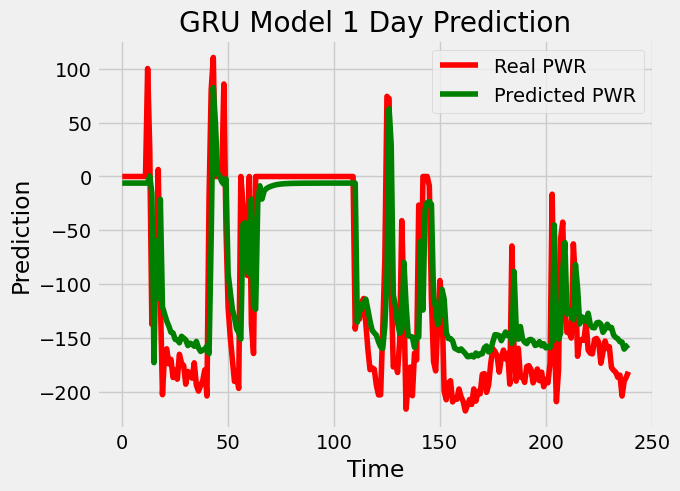

In [70]:
plot_predictions(test_set2,predicted_data2)

In [71]:
return_rmse(test_set2,predicted_data2)

The root mean squared error is 48.09875940981176.


In [72]:
return_mae(test_set2,predicted_data2)

The mean absolute error is 5.89998927886997.


In [73]:
errors = np.abs(test_set2 - predicted_data2)
print("Max error:", errors.max())
print("Mean error:", errors.mean())


Max error: 168.53160095214844
Mean error: 34.80987349078059


In [74]:
from sklearn.metrics import r2_score

r2 = r2_score(test_set2, predicted_data2)
print(f"R² Score: {r2:.4f}")

R² Score: 0.6982


In [75]:
import numpy as np

def accuracy_within_tolerance(y_true, y_pred, tolerance=0.05):
    """
    Calculates the percentage of predictions within a given percentage tolerance.
    
    Parameters:
        y_true (array-like): Actual values
        y_pred (array-like): Predicted values
        tolerance (float): Acceptable percentage error (e.g., 0.05 for 5%)

    Returns:
        accuracy (float): Accuracy as a percentage
    """
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()

    # Avoid division by zero
    nonzero_indices = y_true != 0
    y_true = y_true[nonzero_indices]
    y_pred = y_pred[nonzero_indices]

    relative_errors = np.abs((y_pred - y_true) / y_true)
    within_tolerance = relative_errors <= tolerance
    accuracy = np.mean(within_tolerance) * 100

    print(f"Accuracy within ±{tolerance * 100:.1f}%: {accuracy:.2f}%")
    return accuracy


In [76]:
# Suppose you have actual and predicted values (flattened and inverse-transformed if needed)
accuracy_within_tolerance(test_set2, predicted_data2, tolerance=0.5)  # for 5% tolerance

Accuracy within ±50.0%: 83.72%


83.72093023255815

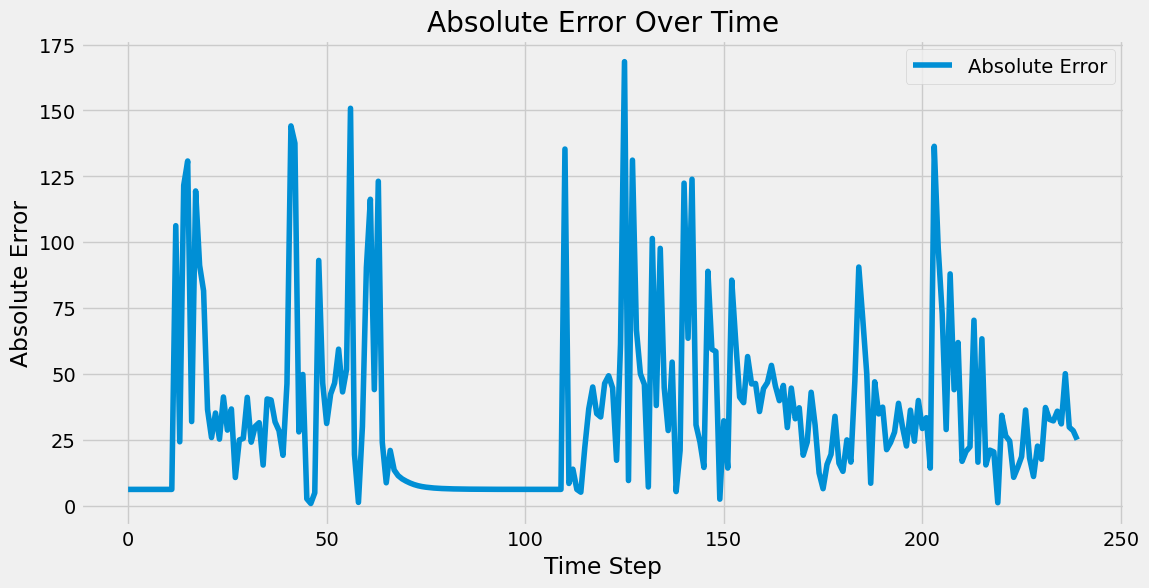

In [77]:
import matplotlib.pyplot as plt

errors = np.abs(test_set2 - predicted_data2)
plt.figure(figsize=(12, 6))
plt.plot(errors, label='Absolute Error')
plt.title('Absolute Error Over Time')
plt.xlabel('Time Step')
plt.ylabel('Absolute Error')
plt.legend()
plt.show()
